# Polinom Regresyonu

Bu notebook'ta, doğrusal olmayan (nonlinear) bir veri setinin standart doğrusal modellerle nasıl eğitilebileceği gösterilmiştir. 

**Uygulama Akışı:**
1. İkinci dereceden, gürültülü (noisy) bir sentetik veri seti üretimi ve görselleştirilmesi.
2. `PolynomialFeatures` kullanarak veri matrisinin arka planda nasıl dönüştürüldüğünün (Özellik Genişletme) incelenmesi.
3. Genişletilmiş matris ile modelin eğitilmesi ve katsayı analizi.
4. Nihai tahmin eğrisinin veri seti üzerinde çizdirilmesi.

### Elle Hesaplamalı Somut Bir Örnek

Polinom regresyonunun arka planda nasıl çalıştığını anlamak için sadece 2 örnekten (satırdan) oluşan minik bir veri seti kurulur.

*   Mevcut ham veri seti (**X** ve **y**):
    *   1. Örnek: $x = 2$ için gerçek sonuç $y = 5$
    *   2. Örnek: $x = 3$ için gerçek sonuç $y = 7$

#### Adım 1: Özellik Genişletme (PolynomialFeatures)
Modele `degree=2` (ikinci derece) yapıldığında, algoritma her bir $x$ değerinin karesini alır ve yanına yeni bir özellik (sütun) olarak ekler:

*   1. Örnek için: $[2] \rightarrow [2, 2^2] \rightarrow [2, 4]$
*   2. Örnek için: $[3] \rightarrow [3, 3^2] \rightarrow [3, 9]$

Artık bilgisayarın elindeki yeni matris (`X_poly`) şu şekildedir:
$$
X_{poly} = \begin{bmatrix} 2 & 4 \\ 3 & 9 \end{bmatrix}
$$

#### Adım 2: Doğrusal Modelin Denklemi Kurması
Standart Doğrusal Regresyon (Linear Regression) algoritması bu matrisi aldığında, iki farklı bağımsız değişken varmış gibi davranır ($x_1$ ve $x_2$). Denklem şudur:
$$ y = \theta_0 + \theta_1 \cdot x_1 + \theta_2 \cdot x_2 $$

Matriste $x_1$ sütununa orijinal veriyi ($x$), $x_2$ sütununa ise verinin karesini ($x^2$) yerleştirildiği için matematiksel denklem otomatik olarak şuna evrilir:
$$ y = \theta_0 + \theta_1 \cdot x + \theta_2 \cdot x^2 $$

#### Adım 3: Katsayıların (Ağırlıkların) Öğrenilmesi
Model eğitim sürecinde (örneğin En Küçük Kareler yöntemiyle) veriye en iyi oturan katsayıları hesaplar. Diyelim ki optimizasyon sonucunda model şu katsayıları buldu:
*   $\theta_0$ (Sabit Sayı / Intercept) = `1.5`
*   $\theta_1$ ($x$'in katsayısı) = `0.8`
*   $\theta_2$ ($x^2$'nin katsayısı) = `0.5`

#### Adım 4: Yeni Bir Değer İçin Tahmin Yapılması
Model artık eğitildi. Sisteme yeni bir veri olarak **$x = 4$** değeri gönderildiğinde arka planda şu hesaplama döner:

1. Önce özellik genişletilir: $x = 4$ ve $x^2 = 16$
2. Değerler bulunan katsayılarla çarpılıp toplanır:
   $$ y_{tahmin} = 1.5 + (0.8 \cdot 4) + (0.5 \cdot 16) $$
   $$ y_{tahmin} = 1.5 + 3.2 + 8.0 = 12.7 $$

Görüldüğü gibi, model doğrusal bir yapıda ($y = \theta_0 + \theta_1 x_1 + \theta_2 x_2$) çalışmasına rağmen, girdi üzerinde yapılan üslü manipülasyon sayesinde hedef değişkeni **eğrisel bir grafik** üzerinde tahmin etmeyi başarmıştır.




### Çoklu Özellikli Somut Bir Örnek (3 Özellik Durumu)

Eğer veri setinde tek bir $x$ yerine 3 farklı özellik ($x_1, x_2, x_3$) bulunuyorsa ve model `degree=2` (ikinci derece) olarak kuruluyorsa, `PolynomialFeatures` sınıfı yalnızca bu özelliklerin karelerini üretmez; aynı zamanda özelliklerin birbirleriyle olan tüm ikili kombinasyonlarını (etkileşim terimlerini) da veri matrisine ekler.

- Mevcut ham veri setindeki tek bir örnek satırı:
  - $x_1 = 2$, $x_2 = 3$, $x_3 = 4$

---

#### Adım 1: Özellik Genişletme (`PolynomialFeatures`)

Algoritma bu 3 değeri alır ve ikinci dereceye kadar oluşturulabilecek tüm kombinasyonları yan yana yerleştirir:

1. **Orijinal Terimler:**  
$$
x_1, x_2, x_3 \rightarrow [2, 3, 4]
$$

2. **Kare Terimleri:**  
$$
x_1^2, x_2^2, x_3^2 \rightarrow [4, 9, 16]
$$

3. **Etkileşim (Kombinasyon) Terimleri:**  
$$
x_1x_2, x_1x_3, x_2x_3 \rightarrow [6, 8, 12]
$$

Genişletme işlemi sonucunda ham haldeki 3 özellik, matriste toplam **9 özellikli** tek bir satıra dönüşür:

$$
[2, 3, 4, 4, 9, 16, 6, 8, 12]
$$

---

#### Adım 2: Formülün Dönüşüm Özeti

### İlk Hali (Standart Doğrusal Regresyon)

Model, veriyi yalnızca her özelliğin kendi ağırlığıyla toplandığı doğrusal bir yapı olarak değerlendirir:

$$
y = \theta_0 + \theta_1x_1 + \theta_2x_2 + \theta_3x_3
$$

### Sonraki Hali (Polinom Regresyon Dönüşümü)

Aynı veri matrisine kare ve kombinasyon terimleri eklendiğinde model arka planda hâlâ doğrusal regresyon mantığıyla çalışır; ancak oluşturulan denklem artık çok boyutlu eğrisel bir yüzeyi temsil eder:

$$
y = \theta_0 + \theta_1x_1 + \theta_2x_2 + \theta_3x_3 + \theta_4x_1^2 + \theta_5x_2^2 + \theta_6x_3^2 + \theta_7x_1x_2 + \theta_8x_1x_3 + \theta_9x_2x_3
$$




> **Kritik Hatırlatma (Kombinasyon Patlaması):**  
> Özellik sayısı yalnızca 3 olmasına rağmen dereceyi 2 yapmak bile sütun sayısını hızlı şekilde artırmıştır. Geron’un kitabında bahsedilen “Kombinasyon Patlaması” problemi, büyük veri setlerinde özellik sayısının bu şekilde kontrolsüz biçimde büyümesini ifade etmektedir.


$$
y = \theta_0 +
\begin{bmatrix}
\theta_1 & \theta_2 & \cdots & \theta_{19}
\end{bmatrix}
\cdot
\begin{bmatrix}
x_1 \\
x_2 \\
x_3 \\
x_1^2 \\
x_2^2 \\
x_3^2 \\
x_1x_2 \\
x_1x_3 \\
x_2x_3 \\
x_1^3 \\
x_2^3 \\
x_3^3 \\
x_1^2x_2 \\
x_1^2x_3 \\
x_2^2x_1 \\
x_2^2x_3 \\
x_3^2x_1 \\
x_3^2x_2 \\
x_1x_2x_3
\end{bmatrix}
=
\begin{aligned}
& \theta_0 + \theta_1x_1 + \theta_2x_2 + \theta_3x_3 + \theta_4x_1^2 + \theta_5x_2^2 + \theta_6x_3^2 + \theta_7x_1x_2 + \theta_8x_1x_3 + \theta_9x_2x_3 \\
&+ \theta_{10}x_1^3 + \theta_{11}x_2^3 + \theta_{12}x_3^3 + \theta_{13}x_1^2x_2 + \theta_{14}x_1^2x_3 + \theta_{15}x_2^2x_1 + \theta_{16}x_2^2x_3 \\
&+ \theta_{17}x_3^2x_1 + \theta_{18}x_3^2x_2 + \theta_{19}x_1x_2x_3
\end{aligned}
$$

### Gerçek Hayat Örneği: Yaş ve Maaş İlişkisi

Sadece yüksek üslü ($x^2$) terimi kullanmanın neden yetersiz olduğunu ve neden hem $x$ hem de $x^2$ teriminin aynı matriste yan yana bulunması gerektiğini anlamak için yaş ($x$) ve maaş ($y$) ilişkisini inceleyelim.

*   **Doğrusal Karakter ($x$):** İnsanlar işe ilk başladıkları 20'li yaşlardan 45'li yaşlara kadar tecrübe kazandıkça maaşları düzenli, düz bir hat şeklinde artar.
*   **Eğrisel Karakter ($x^2$):** 50'li yaşlardan sonra emeklilik planları, çalışma saatlerinin azalması veya sektörel değişimler nedeniyle maaş artışı yavaşlar ve grafik aşağı doğru bükülmeye başlar.

#### Adım 1: Özellik Genişletme
Eğitim setindeki iki çalışanın yaş verileri sisteme girer:
*   Genç Çalışan: $x = 20$
*   Kıdemli Çalışan: $x = 50$

`PolynomialFeatures(degree=2)` bu verileri genişleterek şu matrisi üretir:
$$
X_{poly} = \begin{bmatrix} 20 & 400 \\ 50 & 2500 \end{bmatrix}
$$

#### Adım 2: Modelin Karar Mekanizması
Model eğitilirken iki sütuna da farklı görevler atayan şu katsayıları öğrenir:
*   $\theta_1$ ($x$ yani yaş sütununun katsayısı) = `+2000` *(Pozitif etki: Yaşlandıkça tecrübe artar, maaşı yukarı taşır)*
*   $\theta_2$ ($x^2$ yani yaşın karesi sütununun katsayısı) = `-10` *(Negatif etki: Yaş çok büyüdüğünde karesi devasa büyüklüğe ulaşır ve maaşı aşağı doğru bükmeye başlar)*
*   $\theta_0$ (Taban Maaş) = `10000`

#### Adım 3: İki Terimin Birlikte Çalışması

**20 yaşındaki genç için hesaplama:**
$$ y = 10000 + (2000 \cdot 20) - (10 \cdot 400) $$
$$ y = 10000 + 40000 - 4000 = 46000 $$
*(Gençlik döneminde doğrusal terim baskındır, maaş sağlıklı bir şekilde yükselir).*

**50 yaşındaki kıdemli için hesaplama:**
$$ y = 10000 + (2000 \cdot 50) - (10 \cdot 2500) $$
$$ y = 10000 + 100000 - 25000 = 85000 $$
*(Kıdemli dönemde $x^2$ terimi [$2500$] çok büyüdüğü için negatif katsayının ağırlığı hissedilir ve grafik yukarı doğru dik gitmek yerine sağa/aşağı doğru bükülerek gerçek hayatı taklit eder).*

Eğer matriste sadece $x^2$ olsaydı gençlikteki o kararlı yükseliş trendi kaçacak; sadece $x$ olsaydı yaşlılıktaki yavaşlama ve geriye bükülme asla modellenemeyecekti. İki özelliğin aynı matriste bulunma sebebi budur.


### Formülün Dönüşüm Özeti

*   **İlk Hali (Standart Doğrusal Regresyon):** 
    Model veriyi sadece düz bir çizgi olarak görür:
    $$ y = \theta_0 + \theta_1 \cdot (\text{Yaş}) $$

*   **Sonraki Hali (Polinom Regresyon Dönüşümü):** 
    Aynı matrise yaşın karesi eklenince, model arka planda doğrusal çalışsa da grafik eğriye dönüşür:
    $$ y = \theta_0 + \theta_1 \cdot (\text{Yaş}) + \theta_2 \cdot (\text{Yaş}^2) $$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

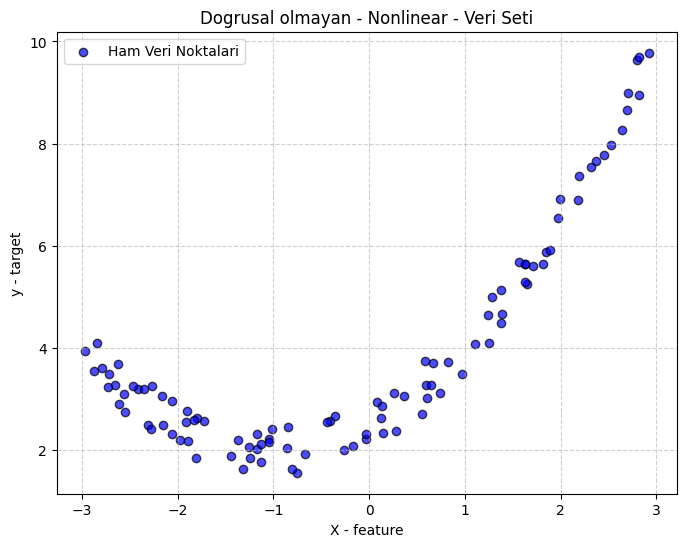

In [7]:
np.random.seed(42)      # tekrarlanabilirlik icin rastgelelik durumunu sabitleme

# 100 adet rastgele X degeri uretme (-3 ile 3 arasinda)
m = 100
X = 6 * np.random.rand(m, 1) - 3

# denklem: y=0.5*x^2 + 1*x + 2 + noisy
y = 0.5 * X**2 + X + 2 + np.random.rand(m,1)

plt.figure(figsize=(8,6))
plt.scatter(X, y, color="blue", alpha=0.7, edgecolor="black", label="Ham Veri Noktalari")
plt.title("Dogrusal olmayan - Nonlinear - Veri Seti")
plt.xlabel("X - feature")
plt.ylabel("y - target")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

In [8]:
from sklearn.preprocessing import PolynomialFeatures

# LinearRegression modelinin kendi bias - sabit terinimi -x^2 terimini eklemek icin dereceyi 2 yapma
# LinearRegression modelinin kendi bias sütununu eklemesi için include_bias=False yapma
poly_features = PolynomialFeatures(degree=2, include_bias=False)

# X matrisini donusturup yeni ozellikler eklenmis X_poly matrisini elde etme
X_poly = poly_features.fit_transform(X)


print("--- ---") 
print("Orijinal X matrisinin ilk elemanı (X[0]):")
print(X[0])
print("\nGenişletilmiş X_poly matrisinin ilk elemanı (X_poly[0]):")
print(X_poly[0])

print("\nDoğrulama:")
print(f"İlk elemanın karesi ({X[0][0]:.6f})^2 =", X[0][0]**2)

--- ---
Orijinal X matrisinin ilk elemanı (X[0]):
[-0.75275929]

Genişletilmiş X_poly matrisinin ilk elemanı (X_poly[0]):
[-0.75275929  0.56664654]

Doğrulama:
İlk elemanın karesi (-0.752759)^2 = 0.5666465440380214
